### 📝 분류(Classification) 성능 평가 지표
##### 정확도(Accuracy)
- 직관적으로 모델 예측 성능을 나타낼 수 있다.
- 2진 분류일 경우 데이터 구성에 따라 타겟 데이터 분포가 불균형할 경우 정확도 한 가지만으로는 적합한 성능 평가 지표가 될 수 없다.
- 강아지와 고양이 모두 무조건 생존으로 예측하는 모델이 있다고 가정한다.  
생존한 강아지 80마리와 사망한 고양이 20마리를 테스트하면, 정확도는 80%이다.  
이 모델을 사용하면 사망한 강아지 혹은 고양이를 절대 예측할 수 없다.
<img src="./images/accuracy01.png" width="400" style="margin: 20px">

##### 오차 행렬(Confusion Matrix)
- 학습된 분류 모델이 예측을 수행하면서 얼마나 예측에 오류가 있는지도 함께 보여주는 지표이다.
- 데이터가 한 곳으로 치우친 것도 확인할 수 있으며, TP, TN, FP, FN, 4가지로 구성되어 있다.
- 오차행렬로 분류 성능 평가 지표의 모든 것을 구할 수 있다(정확도, 정밀도, 재현율, F1 Score, ROC AUC).
<img src="./images/confusion_matrix01.png" width="600" style="margin:20px">

1. TN: 예측한 값은 0이고 실제 값 또한 0일 때  
2. FP: 예측한 값은 1이지만 실제 값은 0일 때  
3. FN: 예측한 값은 0이지만 실제 값은 1일 때  
4. TP: 예측한 값은 1이고 실제 값 또한 1일 때  
- 위 강아지와 고양이의 생존율 예측 모델의 오차 행렬은 다음과 같이 나온다.

<img src="./images/confusion_matrix02.png" width="600" style="margin:20px;">  

- 100마리 전부 생존(음성, Negative)으로 예측했으며, 그 중 80마리는 실제 True이고, 나머지 20마리는 실제 False이기 때문이다.

- 보통 2진 분류일 경우 음성과 양성을 구분하는 의료학에서 많이 사용되며, 2가지 상황으로 나눌 수 있다.
> 1. 질병이나 이상이 없는데도 양성으로 오진하는 것을 방지하기 위해
>> - 특이도(Specificity): 정상을 정상으로 진단하는 비율(▲TN)
>> - 재현율(Recall)이 낮아지고 정밀도(Precision)가 높아질 수 있다.


> 2. 암 진단에서 양성인 환자를 놓치지 않고 최대한 많이 식별하기 위해
>> - 민감도(Sensitivity): 질병이 있는 사람을 질병이 있다고 진단하는 비율(▲TP)
>> - 재현율(Recall)이 높아지고 정밀도(Precision)가 낮아질 수 있다.
- 1의 경우 Positive보다는 Negative 예측 정확도를 높일 것이다. ▲TN 상승, ▼TP 하락. 또한 Positive로 예측하는 경우가 매우 작기 때문에, ▼FP 하락.  
- 2의 경우 Negative보다 Positive 예측 정확도를 높일 것이다, ▲TP 상승, ▼TN 하락, Negative로 예측하는 경우가 매우 작기 때문에, ▼FN 하락.

🚩결과적으로 정확한 판단이 아님에도 불구하고 정확도가 매우 높게 나타나는, 수치적인 판단 오류를 해결하기 위해서는 특이도(Specificity)와 민감도(Sensitivity)를 잘 조절해야 한다.  

### 정밀도와 재현율
<img src="./images/evaluation01.png" width=230 style="margin-left: 10px"> 

##### 정밀도(Precision)
- 예측을 Positive로 한 대상 중, 예측과 실제 값이 Positive로 일치한 데이터의 비율을 뜻한다.
- ▲TP, ▼FP일 경우 정밀도가 상승한다.
- precision_score()를 사용하여 정밀도를 구할 수 있다.

##### 재현율(Recall)
- 실제 값이 Positive인 대상 중, 얼마나 놓치지 않고 Positive로 예측했는 가의 비율을 뜻한다.
- ▲TP, ▼FN일 경우 재현율이 상승한다.
- recall_score()를 사용하여 재현율을 구할 수 있다.

##### 정밀도와 재현율의 트레이드 오프(Trade-off)
- 분류 시 결정 임계값(Threshold)을 조정해서 정밀도 또는 재현율의 수치를 높일 수 있다.  
📌임계값: 분류 시 양성 또는 음성을 판정할 때의 기준점(확률)이며, 임계값을 낮추면 Positive로 예측할 확률이 증가하며  
반대로, 임계값 수치를 올리면 Negative로 더 많이 예측하게 된다.
##### 가정: 구급대원 AI가 교통사고 현장에서 피해자를 병원으로 이송해야 할 지 판단해야 하는 시나리오.

- Dead(Positive): 피해자가 이미 사망했을 경우
- Alive(Negative): 피해자가 아직 살아있을 경우

>True Positive (TP): 모델이 Dead를 Dead로 올바르게 분류한 경우.  
<span style="color: #c85d53">False Positive (FP): 모델이 Alive를 Dead로 잘못 분류한 경우 (error I).</span>  
True Negative (TN): 모델이 Alive를 Alive로 올바르게 분류한 경우.  
<span style="color: #4aa4b4">False Negative (FN): 모델이 Dead를 Alive로 잘못 분류한 경우 (error II).</span>  

`error I의 비용(FP)은 error II의 비용(FN)보다 훨씬 더 치명적인 오류로 간주! Alive로 예측해서 병원에 이송한 뒤 실제 Dead인 것이 낫다. FP ▼, error I ▼.`  

>정밀도 (Precision): 모델이 Dead로 예측한 환자 중에서 실제로 Dead인 환자의 비율을 나타낸다. 즉, 양성(Dead) 클래스로 예측한 결과 중 얼마나 많은 것이 진짜 양성(Dead)인지 측정한다.  
재현율 (Recall): 실제 Dead 피해자 중에서 모델이 Dead로 정확하게 예측한 피해자의 비율을 나타낸다. 즉, 모델이 얼마나 많은 Dead 피해자를 "놓치지 않고" 감지했는지 측정한다.
<img src="./images/threshold.png" width=500 style="margin:20px; margin-left: 0">
> - 🚩이는 정밀도를 높여야 하며, Threshold(임계값)을 높여서(오른쪽으로 이동) FP를 낮추고(정밀도 ▲), FN을 높여야 한다(재현율 ▼). 
> - 즉, Negative(Alive, 음성)로 예측할 확률이 높아져야 소중한 생명을 구할 확률이 높아지고, 이를 위해 임계값을 높여주는 것이다.

- 위의 시나리오처럼 한 쪽의 수치를 강제로 높이면 다른 한 쪽의 수치는 떨어지며, 이를 정밀도와 재현율의 "트레이드 오프"라고 한다.
- 임계치가 높아지면 정밀도가 높아진다. 반대로 임계치가 낮아지면 재현율이 높아진다.

##### F1 Score
- 이진 분류 모델의 성능을 평가하는 지표 중 하나이다.
- 정밀도(Precision)와 재현율(Recall)의 조화평균으로 계산되는 성능 측정 지표이다.  
- 정확도(Accuracy)와 같이 전체 성능에 대한 지표가 아닌 타겟 데이터(class)별 성능을 자세히 분석하는 평가 지표이다.
- 정밀도(Precision)와 재현율(Recall), 두 개의 평가 지표를 모두 고려하여 예측 성능을 평가하기 때문에 두 지표의 평균치를 구하는 조화 평균을 사용하여 조금 더 정확하게 모델의 예측 성능을 평가할 수 있다.
- 텍스트 분류, 정보 검색, 암 진단 등에서 사용되는 모델의 성능을 평가할 수 있다.
> 📌평균
> - 산술 평균(합계)은 큰 데이터에 높은 가중치가 부여되고 기하 평균(곱셈)은 작은 데이터 요소에 낮은 가중치가 부여하는데 비해 조화평균(역수, 비중)은 전체적으로 동일한 가중치가 부여된다.  

<img src="./images/trade_off.png" width=600 style="margin-left: -30px">  

- F1 Score는 0 ~ 1까지 점수를 매길 수 있으며, 0에 가까울 수록 정밀도와 재현율 모두 낮다는 뜻이다.  

##### ROC Curve, AUC
- ROC(Receiver Operating Characteristic)는 수신기 동작 특성이라는 뜻이고, 이러한 이름이 붙은 이유는 2차 세계대전 때 무선 기기 성능 평가 때 사용되었기 때문이다.
- FPR이 변할 때 TPR이 어떻게 변하는지를 나타내는 곡선이며, FPR이 급격히 떨어지더라도 TPR은 천천히 떨어지는 것이 좋은 성능을 가진 모델로 판단한다.  

<img src="./images/roc_auc.png" width=400 style="margin-left: 30px">  

- AUC(Area Under the Curve)는 ROC 곡선 밑의 면적을 구한 것으로서, 일반적으로 1에 가까울 수록 좋은 수치이다.  
- ROC Curve가 축에 붙을 수록(좌상단 모서리) 좋은 성능을 나타내는 것이며, 높이와 밑변이 1인 사각형으로 가정했을 경우 ROC Curve가 축에 붙을 수록(좌상단 모서리) AUC 면적이 넓어지며 1에 가까워진다.  
- 모델이 양성과 음성을 얼마나 잘 분류하는지 시각화할 수 있다. 

🚩정리  
학습 데이터 정확도를 통해 F1 Score를 개선하고(보통 F1 Score가 0.7이상일 때 좋은 모델이라 간주)   F1 Score의 단일값으로 알아낼 수 없는 오차 분포, FPR과 TPR의 상관도를 확인하고자 할 때에는 모델의 성능 평가를 보다 포괄적으로 진행할 수 있는 ROC Curve와 AUC 값을 사용한다.  
성능 개선을 위해 훈련 데이터를 구체적으로 검토하고 모니터링하는 과정이 중요하며, 최종적인 모델의 완성도를 높이는 데에 있어서 평가를 소홀히 해서는 안된다.

### 오차 행렬, 정밀도, 재현율

In [2]:
from sklearn.metrics import accuracy_score, precision_score , recall_score , confusion_matrix, ConfusionMatrixDisplay

# 타겟 데이터와 예측 객체를 전달받는다.
def get_evaluation(y_test, prediction, classifier=None, X_test=None):
#     오차 행렬
    confusion = confusion_matrix(y_test, prediction)
#     정확도
    accuracy = accuracy_score(y_test , prediction)
#     정밀도
    precision = precision_score(y_test , prediction)
#     재현율
    recall = recall_score(y_test , prediction)

    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}')
    print("#" * 50)
    
    if classifier is not None and  X_test is not None:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
        titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

        for (title, normalize), ax in zip(titles_options, axes.flatten()):
            disp = ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax=ax, cmap=plt.cm.Blues, normalize=normalize)
            disp.ax_.set_title(title)
        plt.show()

### 피마 인디언 당뇨병 예측
- 이진 분류(Binary Classification)
##### Featuer
- Pregnancies : 임신 횟수
- Glucose : 경구 포도당 내성 시험에서 2시간 동안 혈장 포도당 농도
- BloodPressure : 혈압 (mm Hg)
- SkinThickness: 삼두근 피부 두께 (mm)
- Insulin: 2시간 혈청 인슐린 (mu U/ml)
- BMI: 체질량지수(kg/(height in m)<sup>2</sup>)
- DiabetesPedigreeFunction: 당뇨병 혈통 기능(유전)
- Age: 나이(만 나이)

##### Target(Label)
- Outcome: 클래스 변수 (0, 음성 또는 1, 양성) 268/768은 1이고 나머지는 0입니다

In [3]:
import numpy as np
import pandas as pd

d_df = pd.read_csv('./datasets/pima_indians_diabetes.csv')
d_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
d_df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [5]:
d_df.duplicated().sum()

np.int64(0)

In [6]:
d_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


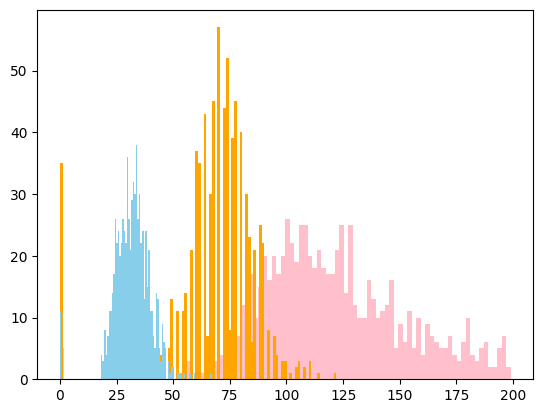

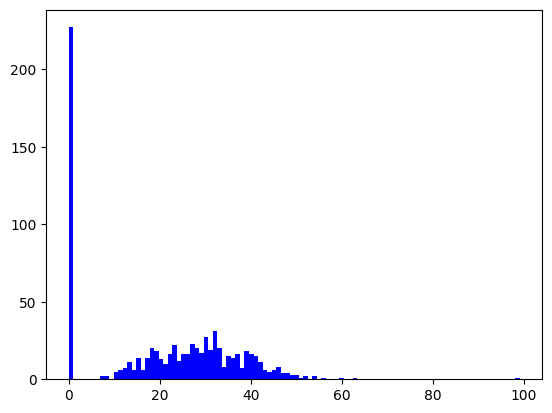

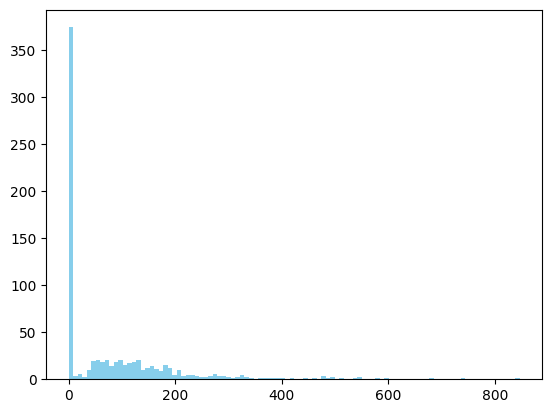

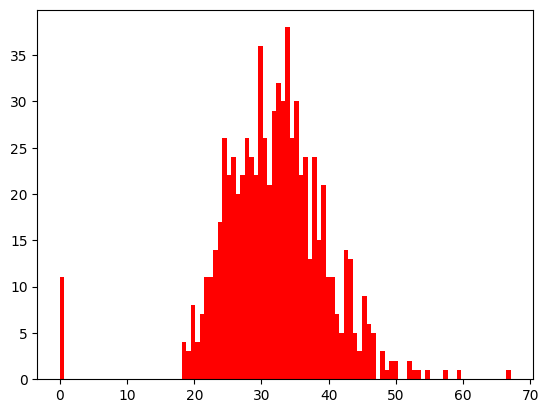

In [7]:
import matplotlib.pyplot as plt

plt.hist(d_df.Glucose, bins=100, color='pink')
plt.hist(d_df.BloodPressure, bins=100, color='orange')
plt.hist(d_df.BMI, bins=100, color='skyblue')
plt.show()

plt.hist(d_df.SkinThickness, bins=100, color='blue')
plt.show()

plt.hist(d_df.Insulin, bins=100, color='skyblue')
plt.show()

plt.hist(d_df.BMI, bins=100, color='red')
plt.show()

In [8]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

total_count = d_df.shape[0]

for feature in zero_features:
    zero_count = d_df[d_df[feature] == 0][feature].count()
    print(f'{feature}: {zero_count}건, {np.round(zero_count / total_count * 100, 4)}%')

Glucose: 5건, 0.651%
BloodPressure: 35건, 4.5573%
SkinThickness: 227건, 29.5573%
Insulin: 374건, 48.6979%
BMI: 11건, 1.4323%


In [9]:
d_df[zero_features] = d_df[zero_features].replace(0, d_df[zero_features].mean())

zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

total_count = d_df.shape[0]

for feature in zero_features:
    zero_count = d_df[d_df[feature] == 0][feature].count()
    print(f'{feature}: {zero_count}건, {np.round(zero_count / total_count * 100, 4)}%')

Glucose: 0건, 0.0%
BloodPressure: 0건, 0.0%
SkinThickness: 0건, 0.0%
Insulin: 0건, 0.0%
BMI: 0건, 0.0%


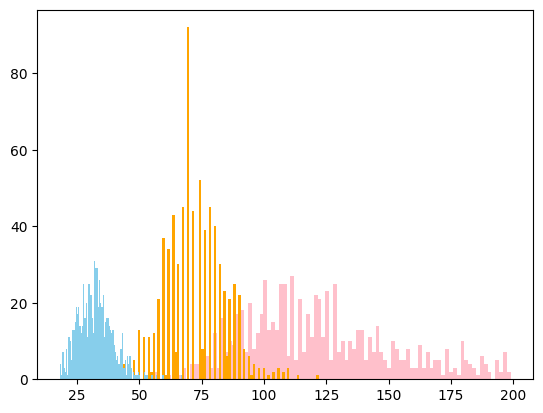

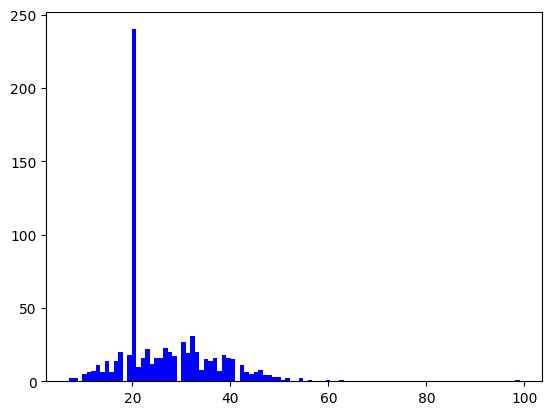

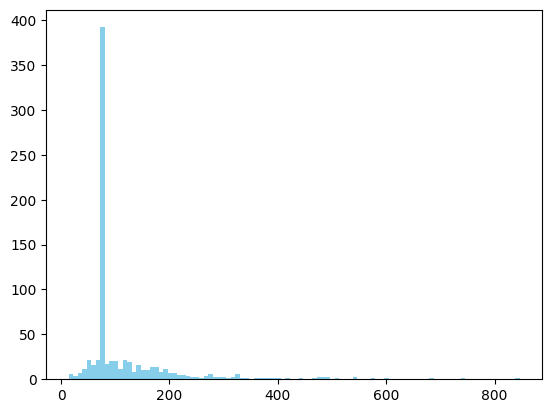

In [10]:
import matplotlib.pyplot as plt

plt.hist(d_df.Glucose, bins=100, color='pink')
plt.hist(d_df.BloodPressure, bins=100, color='orange')
plt.hist(d_df.BMI, bins=100, color='skyblue')
plt.show()

plt.hist(d_df.SkinThickness, bins=100, color='blue')
plt.show()

plt.hist(d_df.Insulin, bins=100, color='skyblue')
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()
std_zero = std.fit_transform(d_df[zero_features])
std_zero

array([[ 0.86527574, -0.0210444 ,  0.87205698, -0.41776815,  0.16725546],
       [-1.20598931, -0.51658286,  0.2486783 , -0.41776815, -0.85153454],
       [ 2.01597855, -0.68176235, -0.6306536 , -0.41776815, -1.33182125],
       ...,
       [-0.02240928, -0.0210444 , -0.37470037, -0.07159946, -0.90975111],
       [ 0.14197684, -1.01212132, -0.6306536 , -0.41776815, -0.34213954],
       [-0.94297153, -0.18622389,  0.45647119, -0.41776815, -0.29847711]],
      shape=(768, 5))

In [12]:
pre_d_df = d_df.copy()
pre_d_df[zero_features] = std_zero
pre_d_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,0.865276,-0.021044,0.872057,-0.417768,0.167255,0.627,50,1
1,1,-1.205989,-0.516583,0.248678,-0.417768,-0.851535,0.351,31,0
2,8,2.015979,-0.681762,-0.630654,-0.417768,-1.331821,0.672,32,1
3,1,-1.074480,-0.516583,-0.374700,-0.265107,-0.633222,0.167,21,0
4,0,0.503626,-2.663916,0.872057,0.530423,1.549899,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,-0.679954,0.309315,2.222711,0.659428,0.065376,0.171,63,0
764,2,0.010468,-0.186224,0.040885,-0.417768,0.632988,0.340,27,0
765,5,-0.022409,-0.021044,-0.374700,-0.071599,-0.909751,0.245,30,0
766,1,0.141977,-1.012121,-0.630654,-0.417768,-0.342140,0.349,47,1


In [13]:
# 그냥 조건식을 쓰면 안됨!!
# condition1 = pre_d_df[zero_features] >= -1.96
# condition2 = pre_d_df[zero_features] <= 1.96

# 하나의 조건이라도 만족하는 행
# condition1 = (pre_d_df[zero_features] >= -3).any(axis=1)
# condition2 = (pre_d_df[zero_features] <= 3).any(axis=1)

# 모든 조건이 만족하는 행
condition1 = (pre_d_df[zero_features] >= -3).all(axis=1)
condition2 = (pre_d_df[zero_features] <= 3).all(axis=1)
condition = condition1 & condition2

pre_d_df = pre_d_df[condition]
pre_d_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,0.865276,-0.021044,0.872057,-0.417768,0.167255,0.627,50,1
1,1,-1.205989,-0.516583,0.248678,-0.417768,-0.851535,0.351,31,0
2,8,2.015979,-0.681762,-0.630654,-0.417768,-1.331821,0.672,32,1
3,1,-1.074480,-0.516583,-0.374700,-0.265107,-0.633222,0.167,21,0
4,0,0.503626,-2.663916,0.872057,0.530423,1.549899,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,-0.679954,0.309315,2.222711,0.659428,0.065376,0.171,63,0
764,2,0.010468,-0.186224,0.040885,-0.417768,0.632988,0.340,27,0
765,5,-0.022409,-0.021044,-0.374700,-0.071599,-0.909751,0.245,30,0
766,1,0.141977,-1.012121,-0.630654,-0.417768,-0.342140,0.349,47,1


In [14]:
d_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [15]:
d_df = d_df.iloc[pre_d_df.index.values, :].reset_index(drop=True)
d_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
730,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
731,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
732,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
733,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

feature, target = d_df.iloc[:, :-1], d_df.iloc[:, -1]
X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, stratify=target, random_state=124)

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

dtc.fit(X_train.values, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,124
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


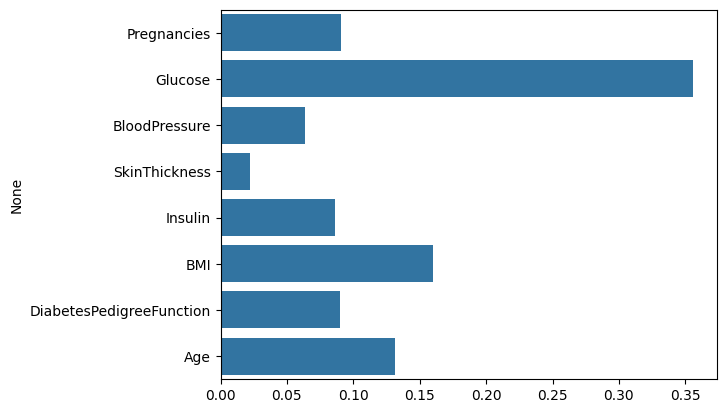

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Classifier의 Decision Boundary를 시각화 하는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    # 호출 파라미터로 들어온 training 데이타로 model 학습 . 
    model.fit(X.values, y)
    # meshgrid 형태인 모든 좌표값으로 예측 수행. 
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # contourf() 를 이용하여 class boundary 를 visualization 수행. 
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow',
                           zorder=1)

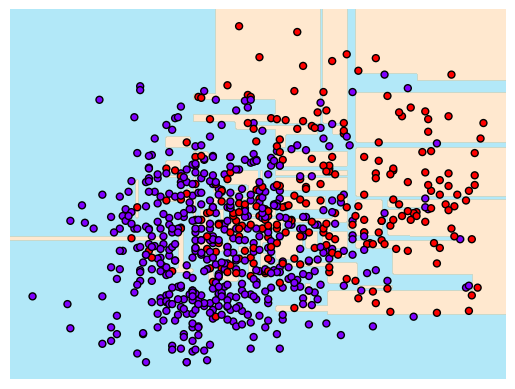

In [19]:
visualize_boundary(dtc, feature[["Glucose", "BMI"]], target)

In [23]:
prediction = dtc.predict(X_test.values)

오차 행렬
[[82 15]
 [20 30]]
정확도: 0.7619, 정밀도: 0.6667, 재현율: 0.6000
##################################################


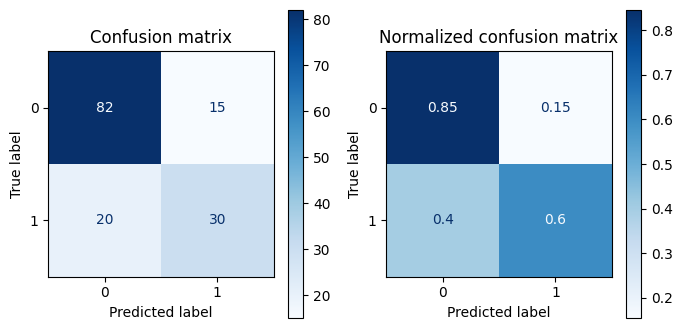

In [24]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

In [25]:
prediction_proba = dtc.predict_proba(X_test.values)
prediction_proba.tolist()

[[1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],

### Feature Engineering
- 중요도가 상대적으로 낮지만 일부 중요한 데이터들을 하나로 합쳐서 새로운 feature를 생성한다.

In [26]:
d_df.drop(columns=['BloodPressure', 'SkinThickness'], axis=1, inplace=True)
d_df

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,79.799479,33.6,0.627,50,1
1,1,85.0,79.799479,26.6,0.351,31,0
2,8,183.0,79.799479,23.3,0.672,32,1
3,1,89.0,94.000000,28.1,0.167,21,0
4,0,137.0,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...
730,10,101.0,180.000000,32.9,0.171,63,0
731,2,122.0,79.799479,36.8,0.340,27,0
732,5,121.0,112.000000,26.2,0.245,30,0
733,1,126.0,79.799479,30.1,0.349,47,1


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

d_scale = scaler.fit_transform(d_df[['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction']])
d_scale

array([[0.35294118, 0.17188191, 0.24841629],
       [0.05882353, 0.17188191, 0.12352941],
       [0.47058824, 0.17188191, 0.26877828],
       ...,
       [0.29411765, 0.25729443, 0.07556561],
       [0.05882353, 0.17188191, 0.12262443],
       [0.05882353, 0.17188191, 0.10723982]], shape=(735, 3))

In [28]:
d_df_scale = d_df.copy()
d_df_scale[['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction']] = d_scale
d_df_scale

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,148.0,0.171882,33.6,0.248416,50,1
1,0.058824,85.0,0.171882,26.6,0.123529,31,0
2,0.470588,183.0,0.171882,23.3,0.268778,32,1
3,0.058824,89.0,0.209549,28.1,0.040271,21,0
4,0.000000,137.0,0.405836,43.1,1.000000,33,1
...,...,...,...,...,...,...,...
730,0.588235,101.0,0.437666,32.9,0.042081,63,0
731,0.117647,122.0,0.171882,36.8,0.118552,27,0
732,0.294118,121.0,0.257294,26.2,0.075566,30,0
733,0.058824,126.0,0.171882,30.1,0.122624,47,1


In [29]:
d_df_scale['score'] = d_df_scale.Pregnancies + d_df_scale.Insulin + d_df_scale.DiabetesPedigreeFunction
d_df_scale

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,score
0,0.352941,148.0,0.171882,33.6,0.248416,50,1,0.773239
1,0.058824,85.0,0.171882,26.6,0.123529,31,0,0.354235
2,0.470588,183.0,0.171882,23.3,0.268778,32,1,0.911248
3,0.058824,89.0,0.209549,28.1,0.040271,21,0,0.308644
4,0.000000,137.0,0.405836,43.1,1.000000,33,1,1.405836
...,...,...,...,...,...,...,...,...
730,0.588235,101.0,0.437666,32.9,0.042081,63,0,1.067983
731,0.117647,122.0,0.171882,36.8,0.118552,27,0,0.408081
732,0.294118,121.0,0.257294,26.2,0.075566,30,0,0.626978
733,0.058824,126.0,0.171882,30.1,0.122624,47,1,0.353330


In [30]:
d_df.drop(columns=['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction'], axis=1, inplace=True)
d_df

,Glucose,BMI,Age,Outcome
0,148.0,33.6,50,1
1,85.0,26.6,31,0
2,183.0,23.3,32,1
3,89.0,28.1,21,0
4,137.0,43.1,33,1
...,...,...,...,...
730,101.0,32.9,63,0
731,122.0,36.8,27,0
732,121.0,26.2,30,0
733,126.0,30.1,47,1


In [31]:
d_df_score = d_df.iloc[:, :-1]
d_df_score['score'] = d_df_scale.score
d_df_score['Outcome'] = d_df.Outcome
d_df_score

,Glucose,BMI,Age,score,Outcome
0,148.0,33.6,50,0.773239,1
1,85.0,26.6,31,0.354235,0
2,183.0,23.3,32,0.911248,1
3,89.0,28.1,21,0.308644,0
4,137.0,43.1,33,1.405836,1
...,...,...,...,...,...
730,101.0,32.9,63,1.067983,0
731,122.0,36.8,27,0.408081,0
732,121.0,26.2,30,0.626978,0
733,126.0,30.1,47,0.353330,1


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

feature, target = d_df_score.iloc[:, :-1], d_df_score.iloc[:, -1]
X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, stratify=target, random_state=124)

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

dtc.fit(X_train.values, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,124
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


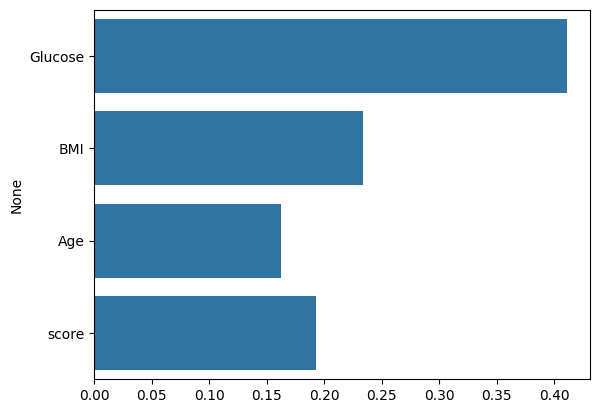

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

In [34]:
prediction = dtc.predict(X_test.values)

오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################


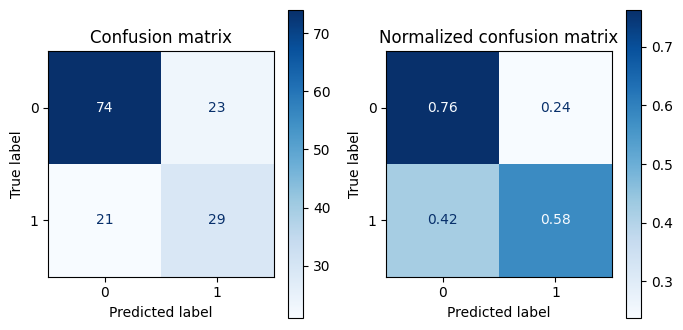

In [35]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

### Precision/Recall Trade-off
##### predict_proba(test features)
- 정밀도(precision), 재현율(recall)의 수치를 각각 나타낼 수 있다.

In [36]:
prediction_proba = dtc.predict_proba(X_test.values)
prediction_proba.tolist()

[[0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [0.0, 1.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],

### Threshold(임계)값과 기준값의 비교
##### Binarizer(threshold)
- 전달한 기준값보다 같거나 작으면 0, 보다 크면 1을 리턴한다.
- predict_proba()의 원리를 이해하자.

In [37]:
from sklearn.preprocessing import Binarizer

proba = [
    [0.4, 0.7, 0.9],
    [0.2, 0, 0.3],
    [0.5, 0.6, 1]
]

# 기준값(threshold) 보다 크면 1, 작거나 같으면 0
binarizer = Binarizer(threshold=0.3)
print(binarizer.fit_transform(proba))

[[1. 1. 1.]
 [0. 0. 0.]
 [1. 1. 1.]]


In [40]:
from sklearn.preprocessing import Binarizer

# 기본값 0.5
# 기존 점수와 바뀔 게 없다.
threshold = 0.5

custom_proba = prediction_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=threshold)
custom_prediction = binarizer.fit_transform(custom_proba)

get_evaluation(y_test, custom_prediction)

오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################


In [41]:
from sklearn.preprocessing import Binarizer

# 타겟 데이터와 예측 객체를 전달받는다.
def get_evaluation_by_thresholds(y_test, prediction_proba_class1, thresholds):
    for threshold in thresholds:
        binarizer = Binarizer(threshold=threshold).fit(prediction_proba_class1) 
        custom_prediction = binarizer.transform(prediction_proba_class1)
        print('임곗값:', threshold)
        get_evaluation(y_test, custom_prediction)

In [42]:
# 기본값 0.5
# 기존 점수와 바뀔 게 없다.
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

custom_proba = prediction_proba[:, 1].reshape(-1, 1)
get_evaluation_by_thresholds(y_test, custom_proba, thresholds)

임곗값: 0.4
오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################
임곗값: 0.45
오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################
임곗값: 0.5
오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################
임곗값: 0.55
오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################
임곗값: 0.6
오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800
##################################################


##### 임계값에 따른 정밀도, 재현율을 한 번에 확인한다.
- precision_recall_curve(test targets, positive rating)
- 정밀도, 재현율, 임계값 순으로 리턴한다.

In [43]:
from sklearn.metrics import precision_recall_curve

prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, -1]

precisions, recalls, thresholds = \
precision_recall_curve(y_test, prediction_proba_class1)

print(thresholds)
print(precisions)
print(recalls)

[0. 1.]
[0.34013605 0.55769231 1.        ]
[1.   0.58 0.  ]


In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test, prediction_proba_class1):

    precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)
    
    # X축: threshold
    # Y축: 정밀도, 재현율 
    # 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # X축(threshold)의 Scale을 0 ~ 1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

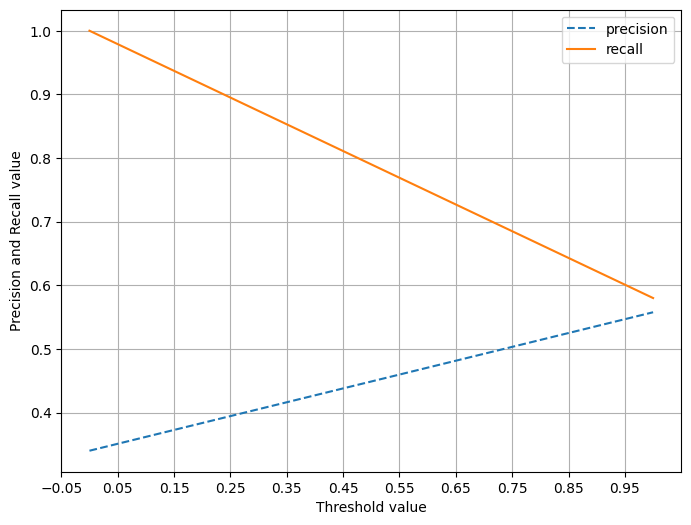

In [45]:
precision_recall_curve_plot(y_test, dtc.predict_proba(X_test.values)[:, 1])

### 정밀도와 재현율의 문제점
- 정밀도를 100%로 만드려면, 확실한 기준이 있을 때에만 Positive로 예측하고 나머지는 모두 Negative로 예측한다. FP: 0, TP: 1
- 재현율을 100%로 만드려면, 모두 Positive로 예측하면 된다. FN: 0, TP: 1 
- 위와 같이 제작할 수 없기 때문에 정밀도와 재현율을 한 쪽으로 치우치지 않도록 해야 하며, 이를 수치로 나타낸 것이 F1 Score이다.

In [47]:
from sklearn.metrics import accuracy_score, precision_score , recall_score , confusion_matrix, ConfusionMatrixDisplay, f1_score

# 타겟 데이터와 예측 객체를 전달받는다.
def get_evaluation(y_test, prediction, classifier=None, X_test=None):
#     오차 행렬
    confusion = confusion_matrix(y_test, prediction)
#     정확도
    accuracy = accuracy_score(y_test , prediction)
#     정밀도
    precision = precision_score(y_test , prediction)
#     재현율
    recall = recall_score(y_test , prediction)
#     F1 score
    f1 = f1_score(y_test, prediction)

    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1 score: {3:.4f}'.format(accuracy , precision ,recall, f1))
    print("#" * 50)
    
    if classifier is not None and  X_test is not None:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
        titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

        for (title, normalize), ax in zip(titles_options, axes.flatten()):
            disp = ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax=ax, cmap=plt.cm.Blues, normalize=normalize)
            disp.ax_.set_title(title)
        plt.show()

In [48]:
get_evaluation(y_test, custom_prediction)

오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800, F1 score: 0.5686
##################################################


### ROC Curve, AUC
##### roc_curve(targets, predict_prob)
- 실제 타겟 데이터와 예측 확률을 전달하면, FPR, TPR, threshold를 리턴한다.

##### roc_auc_score(targets, predict_prob)
- 실제 타겟 데이터와 예측 확률을 전달하면, AUC 값을 리턴한다.

In [1]:
from sklearn.metrics import roc_curve, roc_auc_score

def roc_curve_plot(y_test, prediction_proba_class1, custom_threshold=None):
#     임계값에 따른 FPR, TPR 값
    fprs, tprs, thresholds = roc_curve(y_test ,prediction_proba_class1)

#     ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
#     가운데 대각선 직선을 그림. 
#     TPR과 FPR이 동일한 비율로 떨어진다는 것은 모델이 양성과 음성을 구별하지 못한다는 것을 의미한다.
#     다른 분류기를 판단하기 위한 기준선으로 사용되며, 
#     대각선에 가까울 수록 예측에 사용하기 힘든 모델이라는 뜻이다.
    plt.plot([0, 1], [0, 1], 'k--', label='Standard')

    # 설정한 임계값 지점 표시하기
    if custom_threshold is not None:
        # 설정한 임계값과 가장 가까운 지점 찾기
        idx = np.argmin(np.abs(thresholds - custom_threshold))
        plt.scatter(fprs[idx], tprs[idx], color='red', s=100, 
                    label=f'Threshold: {custom_threshold:.4f}', zorder=5)
        # 지점에 텍스트 추가
        plt.annotate(f'Selected Point ({fprs[idx]:.2f}, {tprs[idx]:.2f})', 
                     (fprs[idx], tprs[idx]), xytext=(fprs[idx]+0.05, tprs[idx]-0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=7))
    
    # X축(FPR)의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

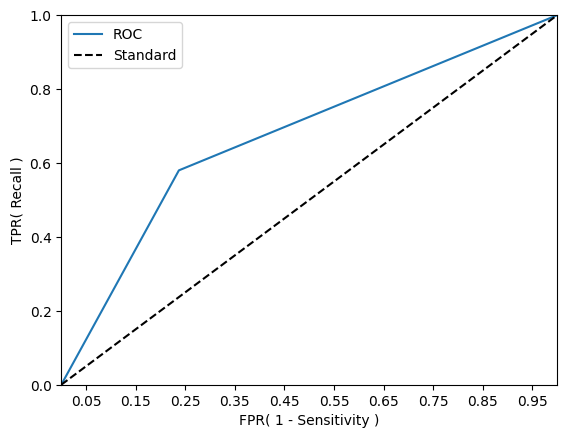

In [44]:
roc_curve_plot(y_test, dtc.predict_proba(X_test.values)[:, 1] )

In [45]:
prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, 1]
binarizer = Binarizer(threshold=0.5)
prediction = binarizer.fit_transform(prediction_proba_class1.reshape(-1, 1))
auc_score = roc_auc_score(y_test, prediction)
print(f'ROC AUC 값: {auc_score}')

ROC AUC 값: 0.6714432989690722


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 평가 지표 출력 및 오차행렬 시각화 함수
def get_evaluation(y_test, prediction):
    # 오차 행렬
    confusion = confusion_matrix(y_test, prediction)
    # 정확도
    accuracy = accuracy_score(y_test, prediction)
    # 정밀도
    precision = precision_score(y_test, prediction)
    # 재현율
    recall = recall_score(y_test, prediction)
    # F1 score
    f1 = f1_score(y_test, prediction)
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, prediction)

    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
    print("#" * 75)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

    for (title, normalize), ax in zip(titles_options, axes.flatten()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true=y_test, y_pred=prediction, ax=ax, cmap=plt.cm.Blues, normalize=normalize
        )
        disp.ax_.set_title(title)
    plt.show()


오차 행렬
[[74 23]
 [21 29]]
정확도: 0.7007, 정밀도: 0.5577, 재현율: 0.5800, F1:0.5686, AUC:0.6714
###########################################################################


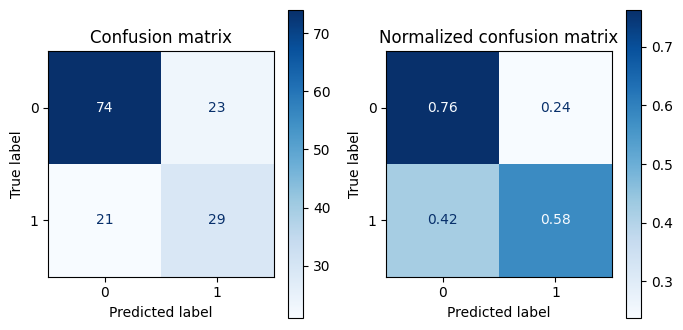

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

feature, target = d_df_score.iloc[:, :-1], d_df_score.iloc[:, -1]
X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, stratify=target, random_state=124)

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

dtc.fit(X_train.values, y_train)

prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, 1]
binarizer = Binarizer(threshold=0.5)
prediction = binarizer.fit_transform(prediction_proba_class1.reshape(-1, 1))
get_evaluation(y_test, prediction, dtc, X_test.values)

#### 과적합시

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

feature, target = d_df.iloc[:, :-1], d_df.iloc[:, -1]
X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, stratify=target, random_state=124)

dtc = DecisionTreeClassifier()

parameters = {
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 20)
}

random_cv = RandomizedSearchCV(
    dtc,
    param_distributions=parameters,
    n_iter=4,
    cv=5,
    refit=True,
    return_train_score=True,
    random_state=124
)

random_cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'max_depth': <scipy.stats....002310E6507F0>, 'min_samples_split': <scipy.stats....002310E2DBFA0>}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [52]:
random_cv_scores = pd.DataFrame(random_cv.cv_results_)
random_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
3,"{'max_depth': 6, 'min_samples_split': 16}",0.729697,1
2,"{'max_depth': 3, 'min_samples_split': 2}",0.727872,2
0,"{'max_depth': 8, 'min_samples_split': 19}",0.716094,3
1,"{'max_depth': 9, 'min_samples_split': 4}",0.709315,4


In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from scipy.stats import randint

feature, target = d_df.iloc[:, :-1], d_df.iloc[:, -1]
X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, stratify=target, random_state=124)

dtc = DecisionTreeClassifier(random_state = 124)

parameters = {
    'max_depth' : list(range(3, 10)),
    'min_samples_split': list(range(2, 20))
}

grid_cv = GridSearchCV(
    dtc,
    param_grid=parameters,
    cv=5,
    refit=True,
    return_train_score=True,
)

grid_cv.fit(X_train.values, y_train)

,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [74]:
dtc = grid_cv.best_estimator_

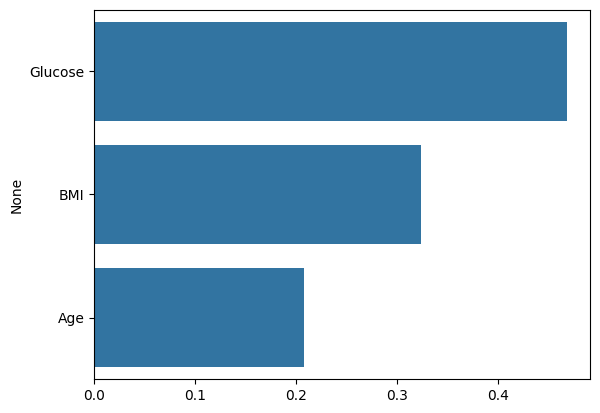

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Classifier의 Decision Boundary를 시각화 하는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    # 호출 파라미터로 들어온 training 데이타로 model 학습 . 
    model.fit(X.values, y)
    # meshgrid 형태인 모든 좌표값으로 예측 수행. 
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # contourf() 를 이용하여 class boundary 를 visualization 수행. 
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow',
                           zorder=1)

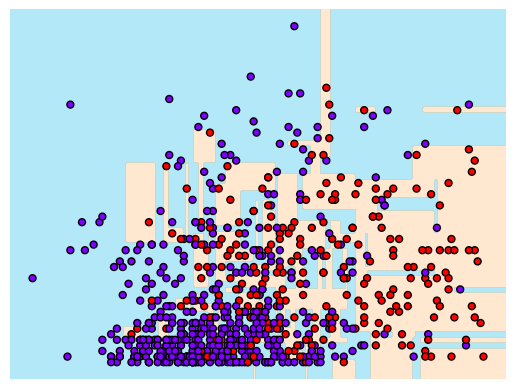

In [54]:
visualize_boundary(dtc, feature[["Glucose", "Age"]], target)

In [70]:
dtc = grid_cv.best_estimator_
prediction = dtc.predict(X_test)

오차 행렬
[[76 21]
 [25 25]]
정확도: 0.6871, 정밀도: 0.5435, 재현율: 0.5000, F1:0.5208, AUC:0.6418
###########################################################################


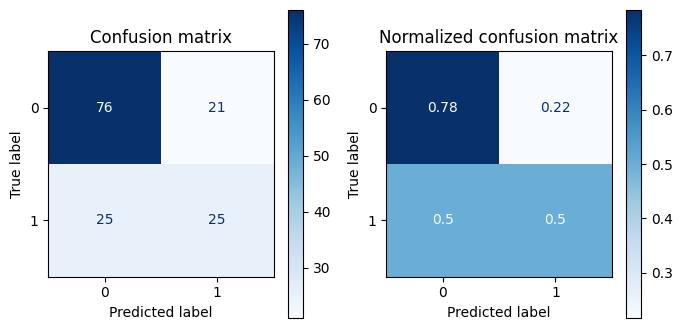

In [61]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test)

In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test, prediction_proba_class1):

    precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)
    
    # X축: threshold
    # Y축: 정밀도, 재현율 
    # 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # X축(threshold)의 Scale을 0 ~ 1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

In [75]:
prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, -1]

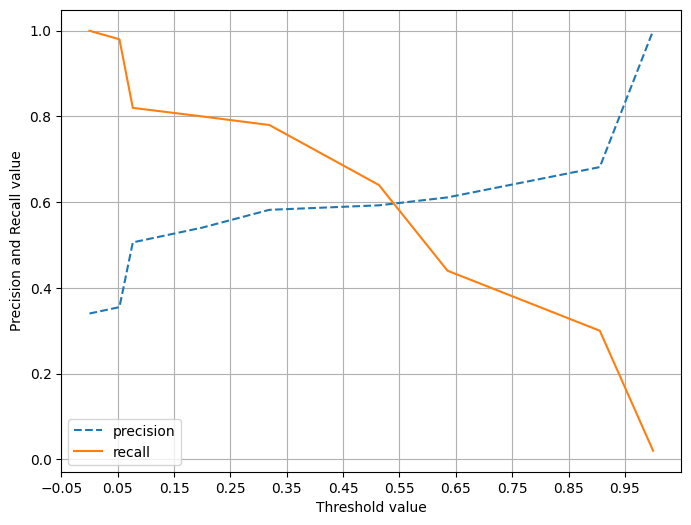

In [76]:
precision_recall_curve_plot(y_test, prediction_proba_class1)

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score

def roc_curve_plot(y_test, prediction_proba_class1):
#     임계값에 따른 FPR, TPR 값
    fprs, tprs, thresholds = roc_curve(y_test ,prediction_proba_class1)

#     ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
#     가운데 대각선 직선을 그림. 
#     TPR과 FPR이 동일한 비율로 떨어진다는 것은 모델이 양성과 음성을 구별하지 못한다는 것을 의미한다.
#     다른 분류기를 판단하기 위한 기준선으로 사용되며, 
#     대각선에 가까울 수록 예측에 사용하기 힘든 모델이라는 뜻이다.
    plt.plot([0, 1], [0, 1], 'k--', label='Standard')
    
    # X축(FPR)의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

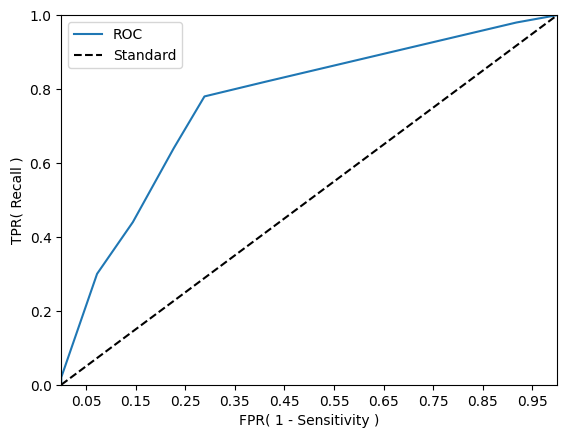

In [78]:
roc_curve_plot(y_test, prediction_proba_class1)

In [82]:
from sklearn.metrics import precision_recall_curve

prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, -1]

precisions, recalls, thresholds = \
precision_recall_curve(y_test, prediction_proba_class1)

print(thresholds)
print(precisions)
print(recalls)
# 0.31914894

[0.         0.05319149 0.07692308 0.2        0.31914894 0.51351351
 0.63529412 0.90540541 1.        ]
[0.34013605 0.35507246 0.50617284 0.54054054 0.58208955 0.59259259
 0.61111111 0.68181818 1.         1.        ]
[1.   0.98 0.82 0.8  0.78 0.64 0.44 0.3  0.02 0.  ]


In [83]:
prediction_proba_class1 = dtc.predict_proba(X_test.values)[:, 1]
binarizer = Binarizer(threshold=0.31914894)
prediction = binarizer.fit_transform(prediction_proba_class1.reshape(-1, 1))
auc_score = roc_auc_score(y_test, prediction)
print(f'ROC AUC 값: {auc_score}')

ROC AUC 값: 0.7065979381443299


오차 행렬
[[75 22]
 [18 32]]
정확도: 0.7279, 정밀도: 0.5926, 재현율: 0.6400, F1:0.6154, AUC:0.7066
###########################################################################


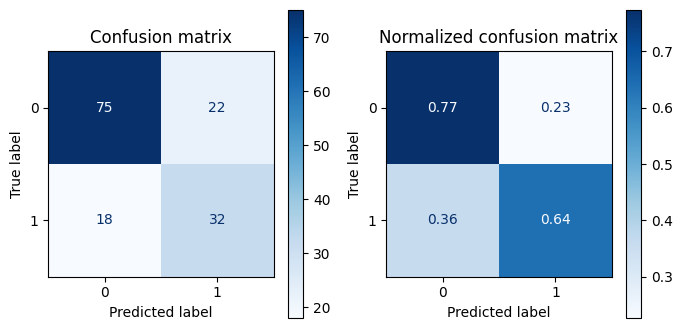

In [85]:
get_evaluation(y_test, prediction, classifier=dtc, X_test=X_test.values)

##### 🚩정리

1. 여러 개의 임계값에 대한 정밀도와 재현율을 확인한다.
> precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)
> precision_recall_curve_plot(y_test, prediction_proba_class1)

2. 위의 임계값에 대한 다양한 평가 지표를 확인한다.
> get_evaluation_by_thresholds(y_test, prediction_proba_class1.reshape(-1, 1), thresholds)

3. 원하는 임계값으로 설정하여 다시 한 번 다양한 평가 지표를 확인한다.
> prediction_proba = grid_decision_tree.predict_proba(X_test)[:, 1].reshape(-1, 1)  
> prediction = Binarizer(threshold=0.52).fit_transform(prediction_proba)  
> get_evaluation(y_test, prediction, grid_decision_tree, X_test)  

4. 해당 임계값으로 설정된 모델의 prediction을 사용한다.

In [57]:
from sklearn.preprocessing import Binarizer

# 타겟 데이터와 예측 객체를 전달받는다.
def get_evaluation_by_thresholds(y_test, prediction_proba_class1, thresholds):
    for threshold in thresholds:
        binarizer = Binarizer(threshold=threshold).fit(prediction_proba_class1) 
        custom_prediction = binarizer.transform(prediction_proba_class1)
        print('임곗값:', threshold)
        get_evaluation(y_test, custom_prediction)

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test, prediction_proba_class1):

    precisions, recalls, thresholds = precision_recall_curve(y_test, prediction_proba_class1)
    
    # X축: threshold
    # Y축: 정밀도, 재현율 
    # 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # X축(threshold)의 Scale을 0 ~ 1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def roc_curve_plot(y_test, prediction_proba_class1):
#     임계값에 따른 FPR, TPR 값
    fprs, tprs, thresholds = roc_curve(y_test ,prediction_proba_class1)

#     ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
#     가운데 대각선 직선을 그림. 
#     TPR과 FPR이 동일한 비율로 떨어진다는 것은 모델이 양성과 음성을 구별하지 못한다는 것을 의미한다.
#     다른 분류기를 판단하기 위한 기준선으로 사용되며, 
#     대각선에 가까울 수록 예측에 사용하기 힘든 모델이라는 뜻이다.
    plt.plot([0, 1], [0, 1], 'k--', label='Standard')
    
    # X축(FPR)의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 평가 지표 출력 및 오차행렬 시각화 함수
def get_evaluation(y_test, prediction):
    # 오차 행렬
    confusion = confusion_matrix(y_test, prediction)
    # 정확도
    accuracy = accuracy_score(y_test, prediction)
    # 정밀도
    precision = precision_score(y_test, prediction)
    # 재현율
    recall = recall_score(y_test, prediction)
    # F1 score
    f1 = f1_score(y_test, prediction)
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, prediction)

    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
    print("#" * 75)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

    for (title, normalize), ax in zip(titles_options, axes.flatten()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true=y_test, y_pred=prediction, ax=ax, cmap=plt.cm.Blues, normalize=normalize
        )
        disp.ax_.set_title(title)
    plt.show()
